# Proiect: Detecția muchiilor în imagini
### Materia: Inteligență artificală în prelucrarea imaginilor
### Student: Droc Viviana-Erika
### An universitar: 2025

Ca si prim pas, instalam opencv si alte librarii folosite

In [1]:
!pip install opencv-python matplotlib numpy scikit-image

   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   -- ------------------------------------- 2.6/39.0 MB 18.9 MB/s eta 0:00:02
   -------- ------------------------------- 8.1/39.0 MB 24.9 MB/s eta 0:00:02
   ------------- -------------------------- 13.1/39.0 MB 23.4 MB/s eta 0:00:02
   --------------------------- ------------ 27.0/39.0 MB 35.3 MB/s eta 0:00:01
   -------------------------------------- - 38.0/39.0 MB 39.2 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 35.4 MB/s eta 0:00:00


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters

Coduri/experimente preluate din exercitiile de la curs (am preluat codurile din materialul de curs si le-am convertit din MATLAB in Python pt a putea rula in Jupyter Notebook)

I. Operatori clasici (Prewitt, Sobel, Roberts)

🔸 corespondent: filter2_Sobel, filter2_Prewitt, filter2_Roberts

### Operatorul Sobel

- calculeaza derivata imaginii în directiile X și Y, oferind o masura a intensitatii si directiei gradientului.  
- rezultatele combinate (magnitudinea și unghiul) indica pozitia si orientarea muchiilor.


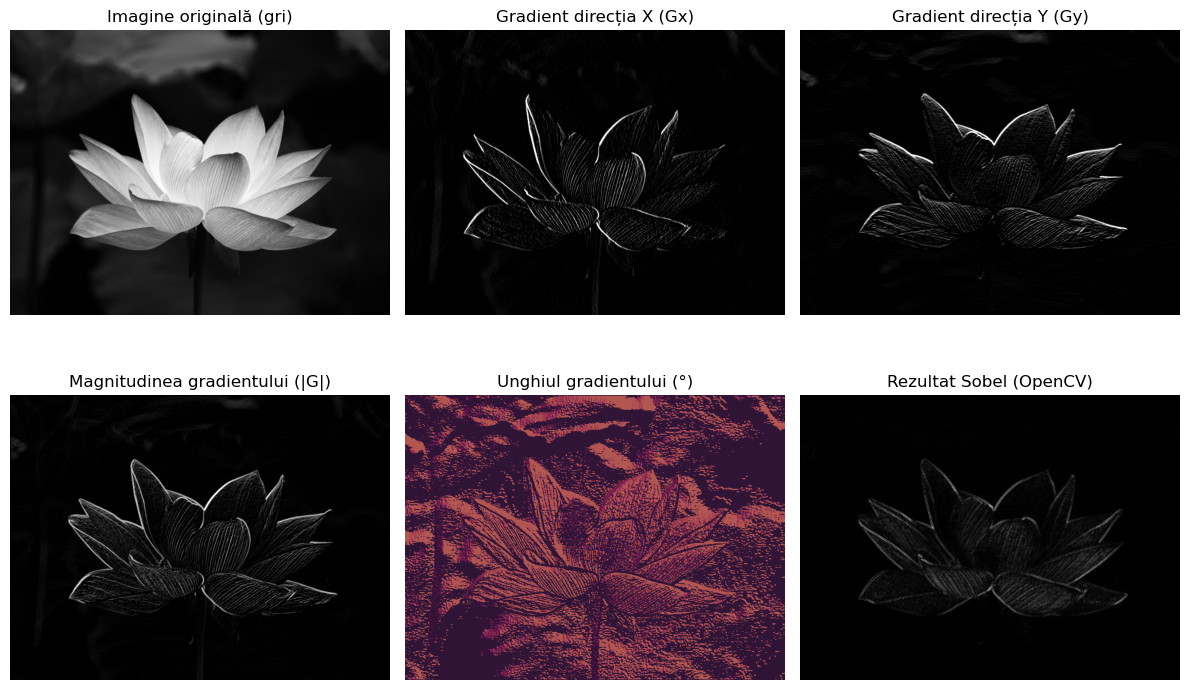

In [49]:
# -------------------------------
# DETECTIA MUCHIILOR - OPERATORUL SOBEL
# -------------------------------

# Citirea imaginii
img = cv2.imread('lotus.jpg')
if img is None:
    raise FileNotFoundError("Imaginea lotus.jpg nu a fost găsită. Verifică calea!")

# Conversie la gri (echivalent rgb2gray)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#  Definirea mastilor Sobel
Sobelx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)
Sobely = Sobelx.T  # transpusul lui Sobelx

# Aplicarea filtrului (echivalent filter2)
Gx = cv2.filter2D(gray, -1, Sobelx)
Gy = cv2.filter2D(gray, -1, Sobely)

# Magnitudinea gradientului
J = np.sqrt(Gx.astype(float)**2 + Gy.astype(float)**2)
J = cv2.normalize(J, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# eliminarea muchiilor de pe margini (ca în codul MATLAB)
J[0, :] = 0
J[:, 0] = 0

# Unghiul gradientului (in grade)
unghi = np.arctan2(Gy.astype(float), Gx.astype(float)) * 180 / np.pi

# Rezultatul final: aplicarea Sobel nativă din OpenCV pentru comparație
BW = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)
BW = np.uint8(np.absolute(BW))

# Afișare rezultate
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Imagine originală (gri)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(Gx, cmap='gray')
plt.title('Gradient direcția X (Gx)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(Gy, cmap='gray')
plt.title('Gradient direcția Y (Gy)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(J, cmap='gray')
plt.title('Magnitudinea gradientului (|G|)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(unghi, cmap='twilight', vmin=-180, vmax=180)
plt.title('Unghiul gradientului (°)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(BW, cmap='gray')
plt.title('Rezultat Sobel (OpenCV)')
plt.axis('off')

plt.tight_layout()
plt.show()


### Operatorul Prewitt
Operatorul Prewitt este un filtru de derivare de ordinul 1 utilizat pentru detecția muchiilor.  
El calculeaza variatiile de intensitate in directiile orizontala si verticala prin convolutia imaginii cu doua măști 3x3.  
Rezultatul este o imagine a magnitudinii gradientului, care evidențiază muchiile.


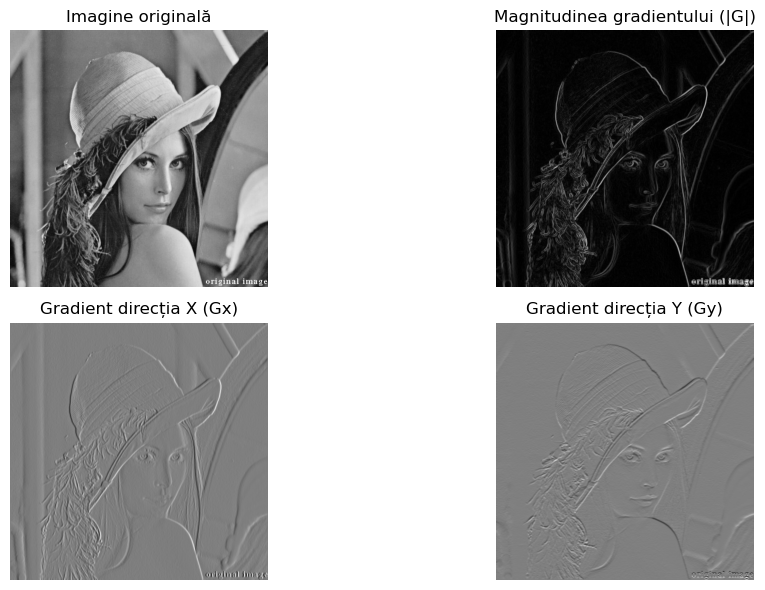

In [54]:
# -------------------------------
# DETECTIA MUCHIILOR - OPERATORUL PREWITT
# -------------------------------

# Citirea imaginii
img = cv2.imread('woman.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Imaginea woman.jpg nu a fost găsită. Verifică calea!")

# Definirea mastilor Prewitt
Prewittx = np.array([[1, 0, -1],
                     [1, 0, -1],
                     [1, 0, -1]], dtype=np.float32)

Prewitty = np.array([[1, 1, 1],
                     [0, 0, 0],
                     [-1, -1, -1]], dtype=np.float32)

# Aplicarea filtrarii (echivalent filter2 în MATLAB)
Gx = cv2.filter2D(img, cv2.CV_64F, Prewittx)
Gy = cv2.filter2D(img, cv2.CV_64F, Prewitty)

# Magnitudinea gradientului
Gmag = np.sqrt(Gx**2 + Gy**2)
Gmag = cv2.normalize(Gmag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Detectarea muchiilor folosind metoda Prewitt (implementare manuală)
edges_manual = Gmag > 50  

# Comparare cu metoda edge-type (prin Sobel ca referință)
# OpenCV nu are direct cv2.Prewitt(), dar putem simula cu kernelul definit
edges_auto = Gmag

# Afișare rezultate
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagine originală')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(Gmag, cmap='gray')
plt.title('Magnitudinea gradientului (|G|)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(Gx, cmap='gray')
plt.title('Gradient direcția X (Gx)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(Gy, cmap='gray')
plt.title('Gradient direcția Y (Gy)')
plt.axis('off')

plt.tight_layout()
plt.show()


In [55]:
H, W = gray.shape
edges_prewitt_resized = cv2.resize(edges_auto, (W, H), interpolation=cv2.INTER_LINEAR)

psnr_prewitt = compute_psnr(gray, edges_prewitt_resized)
contrast_prewitt = compute_contrast(edges_prewitt_resized)
hist_prewitt = compute_histogram_value(edges_prewitt_resized)

### Operatorul Roberts Cross
Operatorul Roberts Cross este unul dintre cei mai simpli detectoare de muchii, introdus în 1963.  
Folosește două măști 2×2 pentru a calcula variațiile diagonale de intensitate, oferind o estimare rapidă a gradientului.  
Este potrivit pentru evidențierea muchiilor fine, dar este sensibil la zgomot din cauza dimensiunii reduse a kernelului.


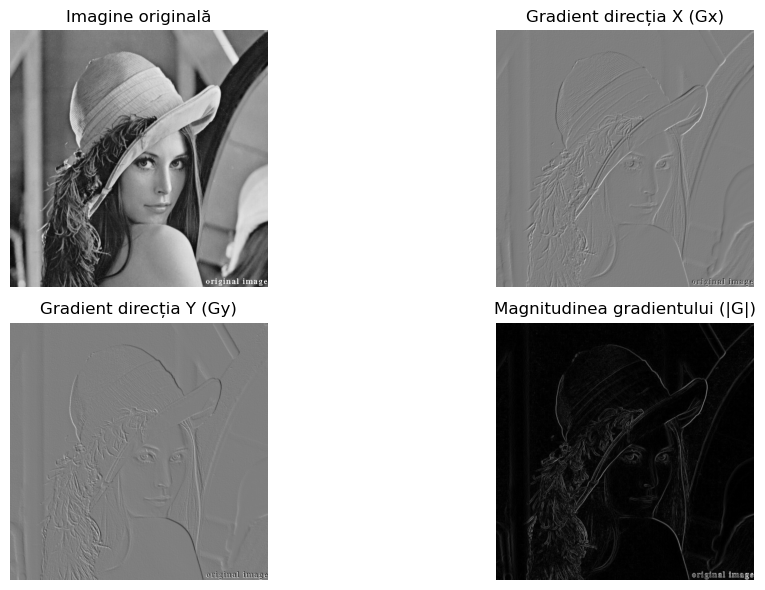

In [58]:
# -------------------------------
# DETECȚIA MUCHIILOR - OPERATORUL ROBERTS CROSS
# -------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('woman.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Imaginea woman.jpg nu a fost găsită. Verifică calea!")

# Definirea măștilor Roberts Cross (2x2)
RobertsX = np.array([[1, 0],
                     [0, -1]], dtype=np.float32)

RobertsY = np.array([[0, 1],
                     [-1, 0]], dtype=np.float32)

# Aplicarea filtrării 
Gx = cv2.filter2D(img, cv2.CV_64F, RobertsX)
Gy = cv2.filter2D(img, cv2.CV_64F, RobertsY)

# Magnitudinea gradientului (combinare direcții)
Gmag = np.sqrt(Gx**2 + Gy**2)
Gmag = cv2.normalize(Gmag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Prag simplu pentru binarizarea muchiilor
edges_roberts = Gmag > 50

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagine originală')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(Gx, cmap='gray')
plt.title('Gradient direcția X (Gx)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(Gy, cmap='gray')
plt.title('Gradient direcția Y (Gy)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(Gmag, cmap='gray')
plt.title('Magnitudinea gradientului (|G|)')
plt.axis('off')

plt.tight_layout()
plt.show()


### Laplacian of Gaussian
II. Derivata de ordin 2 – Laplacian of Gaussian (LoG)

🔸 corespondent: filter2_LoG, plot_LoG2D

Operatorul LoG combină două etape:
1. Netezirea imaginii printr-un filtru Gaussian (pentru reducerea zgomotului);
2. Aplicarea operatorului Laplacian (derivată de ordinul 2).

Muchiile sunt localizate în zonele unde rezultatul filtrării trece prin zero (zero-crossing).  
Parametrul σ controlează scara filtrului:
- σ mare → muchii mai groase, dar se pierd detalii fine;
- σ mic → muchii fine, dar mai mult zgomot.


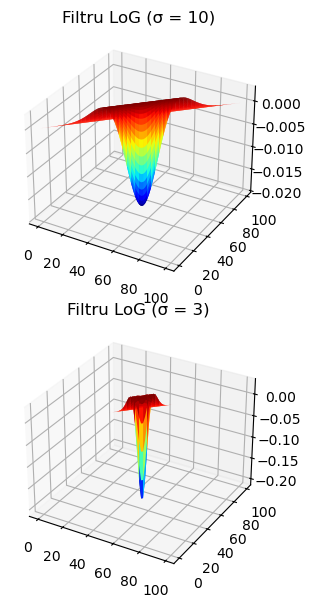

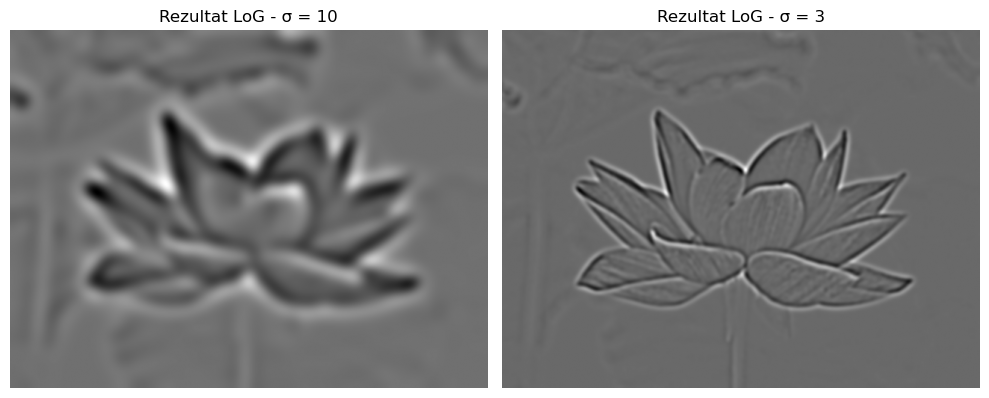

In [14]:
# -------------------------------
# DETECTIA MUCHIILOR - LAPLACIAN OF GAUSSIAN (LoG)
# -------------------------------

from scipy import ndimage

# Citirea imaginii (grayscale)
img = cv2.imread('lotus.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Imaginea lotus.jpg nu a fost găsită. Verifică calea!")

# Definirea funcției pentru filtrul LoG (echivalent fspecial('log'))
def laplacian_of_gaussian(size, sigma):
    """Creează un filtru Laplacian of Gaussian de dimensiune 'size' și deviație 'sigma'."""
    n = (size - 1) / 2
    y, x = np.ogrid[-n:n+1, -n:n+1]
    norm = (x**2 + y**2 - 2 * sigma**2) / sigma**4
    gaussian = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    log_filter = norm * gaussian
    log_filter -= log_filter.mean()  # elimină offsetul
    return log_filter

# Crearea filtrelor LoG cu două valori diferite de sigma
h10 = laplacian_of_gaussian(100, 10)
h3 = laplacian_of_gaussian(100, 3)

# Vizualizarea suprafețelor filtrului
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(2, 1, 1, projection='3d')
ax1.plot_surface(np.arange(100), np.arange(100), h10, cmap='jet', edgecolor='none')
ax1.set_title('Filtru LoG (σ = 10)')

ax2 = fig.add_subplot(2, 1, 2, projection='3d')
ax2.plot_surface(np.arange(100), np.arange(100), h3, cmap='jet', edgecolor='none')
ax2.set_title('Filtru LoG (σ = 3)')

plt.tight_layout()
plt.show()

# Aplicarea filtrului LoG asupra imaginii (echivalent filter2)
LoG10 = ndimage.convolve(img.astype(float), h10)
LoG3 = ndimage.convolve(img.astype(float), h3)

# Afișarea rezultatelor
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(LoG10, cmap='gray')
plt.title('Rezultat LoG - σ = 10')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(LoG3, cmap='gray')
plt.title('Rezultat LoG - σ = 3')
plt.axis('off')

plt.tight_layout()
plt.show()


III. Difference of Gaussians (DoG)

🔸 corespondent: plot_DoG

- DoG are avantajul că este mai rapid de calculat decât LoG și oferă rezultate similare

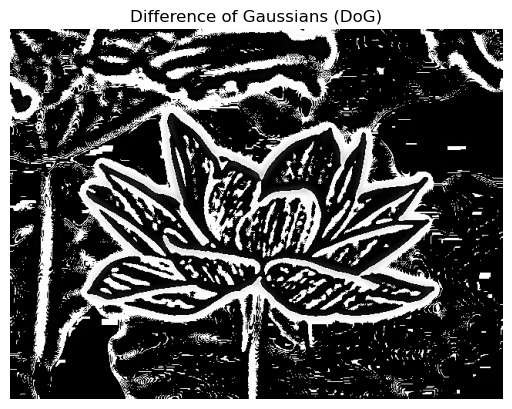

In [4]:
import scipy.ndimage as nd

G1 = nd.gaussian_filter(gray, sigma=2)
G2 = nd.gaussian_filter(gray, sigma=4)
DoG = G1 - G2

plt.imshow(DoG, cmap='gray')
plt.title("Difference of Gaussians (DoG)")
plt.axis('off')
plt.show()


### Detecția muchiilor folosind Sobel, Laplacian și Canny
Aceste metode evidențiază zonele din imagine unde intensitatea pixelilor se schimbă brusc.

🔸 corespondent: Exmple_OpenCV

Ce face acest cod:

- înlocuiește imshow() cu matplotlib, astfel încât imaginile se afișează direct în notebook;

- face conversia la gri (pentru filtrele de detecție);

- aplică Sobel, Laplacian, și Canny la fel ca în C++;

- nu mai are nevoie de waitKey() sau destroyAllWindows() 

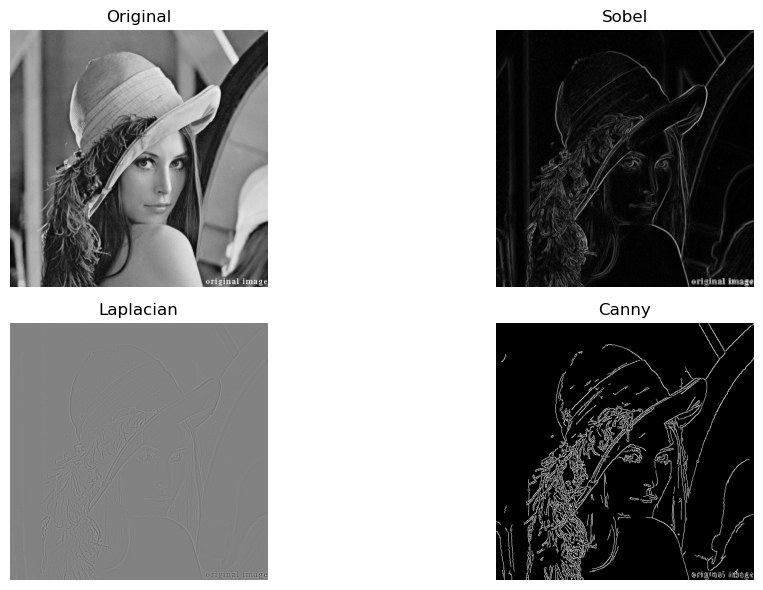

In [61]:
# Pentru afișare clară în notebook
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = False

#  Citirea imaginii
src = cv2.imread("woman.jpg")

if src is None:
    raise FileNotFoundError("Imaginea nu a fost găsită. Verifică numele fișierului sau calea.")

# Conversie în tonuri de gri
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

#  Aplicare Sobel (derivate de ordinul 1)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

#  Aplicare Laplacian (derivată de ordinul 2)
laplacian = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)

#  Aplicare Canny
canny = cv2.Canny(gray, 100, 200)

#  Afișare rezultate
titles = ['Original', 'Sobel', 'Laplacian', 'Canny']
images = [gray, sobel_combined, laplacian, canny]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


### Detector Canny

##### Explorarea scale space-ului cu Canny și Gaussian Blur
Filtrarea Gaussiană este controlată de parametrul σ (sigma), care definește scara de analiză a imaginii.  
Cu cât valoarea lui σ este mai mare, cu atât imaginea este mai netezită, iar numărul de muchii detectate scade.  
Acest fenomen este specific analizei în *scale space* și ilustrează relația dintre nivelul de detaliu și detecția contururilor.

experiment preluat din articolul: https://cave.cs.columbia.edu/Statics/monographs/Edge%20Detection%20FPCV-2-1.pdf


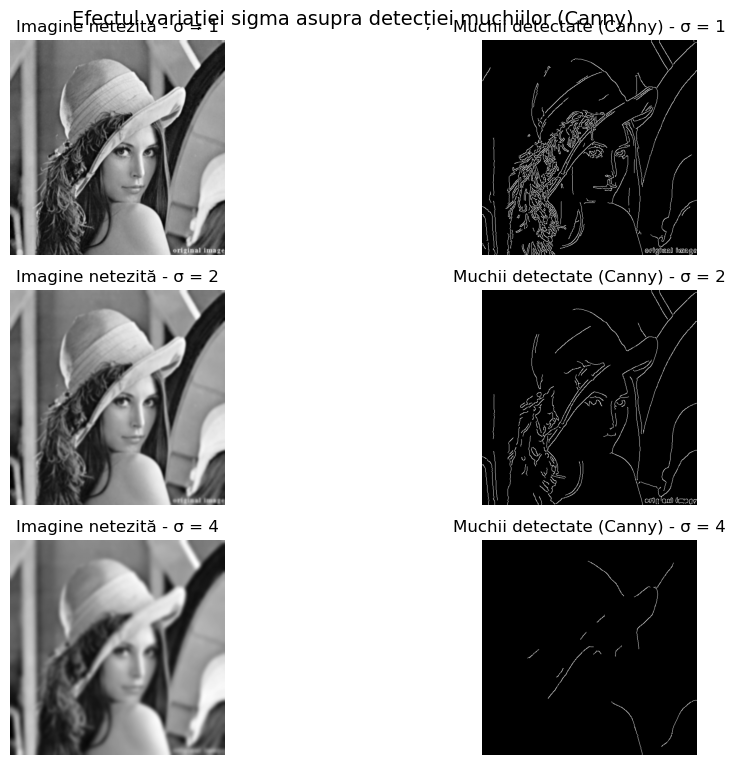

In [16]:
# -------------------------------
# EXPLORAREA SCALE SPACE-ULUI - EFECTUL VARIAȚIEI SIGMA ÎN CANNY
# -------------------------------

# Citirea imaginii
img = cv2.imread('woman.jpg')
if img is None:
    raise FileNotFoundError("Imaginea lotus.png nu a fost găsită. Verifică calea!")

# Conversie la gri
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Valorile sigma pentru test
sigmas = [1, 2, 4]
edges_list = []

for s in sigmas:
    # Aplicare Gaussian blur cu sigma variabil
    blurred = cv2.GaussianBlur(gray, (0, 0), sigmaX=s)
    
    # Aplicare detector Canny
    edges = cv2.Canny(blurred, 70, 135)
    
    edges_list.append((s, blurred, edges))

# Afișarea rezultatelor
plt.figure(figsize=(12, 8))

for i, (sigma, blurred, edges) in enumerate(edges_list):
    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'Imagine netezită - σ = {sigma}')
    plt.axis('off')
    
    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(edges, cmap='gray')
    plt.title(f'Muchii detectate (Canny) - σ = {sigma}')
    plt.axis('off')

plt.suptitle("Efectul variației sigma asupra detecției muchiilor (Canny)", fontsize=14, y=0.95)
plt.tight_layout()
plt.show()



# Edge detection comparative analysis
experiment preluat din articolul: Utama, K.M.R.A., Umar, R. and Yudhana, A., 2022. Edge detection comparative analysis using Roberts, Sobel, Prewitt, and Canny methods. Jurnal teknologi dan sistem komputer, 10(2), pp.67-71.

##### PSNR
- Cât de asemănătoare este imaginea procesată față de original (valoare mare = imagini similare)
- Aici e invers util: imaginea cu muchii e foarte diferită de original → PSNR va fi mic (măsoară cât de “agresiv” e filtrul).

##### Contrast
- Diferența de luminozitate între regiuni
- Imaginea cu muchii are contrast puternic între fundal și contururi – putem folosi deviația standard a intensității.

##### Histogramă
- Distribuția valorilor pixelilor
- Arată cât de “sparse” e imaginea de muchii – adică cât de mult din imagine e alb (muchii).

In [45]:
def compute_psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 10 * np.log10((255 ** 2) / mse)
    return psnr


In [46]:
def compute_contrast(img):
    return np.std(img)


In [47]:
def compute_histogram_value(img):
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    hist_norm = hist / np.sum(hist)
    entropy = -np.sum(hist_norm * np.log2(hist_norm + 1e-8))
    return entropy


In [53]:
# -------------------------------
# Calculare pentru Sobel
# -------------------------------

H, W = gray.shape
edges_sobel_resized = cv2.resize(edges_sobel, (W, H), interpolation=cv2.INTER_LINEAR)

psnr_sobel = compute_psnr(gray, edges_sobel_resized)
contrast_sobel = compute_contrast(edges_sobel_resized)
hist_sobel = compute_histogram_value(edges_sobel_resized)

In [56]:
# -------------------------------
# Calculare pentru Prewitt
# -------------------------------

H, W = gray.shape
edges_prewitt_resized = cv2.resize(edges_auto, (W, H), interpolation=cv2.INTER_LINEAR)

psnr_prewitt = compute_psnr(gray, edges_prewitt_resized)
contrast_prewitt = compute_contrast(edges_prewitt_resized)
hist_prewitt = compute_histogram_value(edges_prewitt_resized)

In [59]:
# -------------------------------
# Calculare pentru Roberts
# -------------------------------

H, W = gray.shape
edges_roberts_resized = cv2.resize(edges_auto, (W, H), interpolation=cv2.INTER_LINEAR)

psnr_roberts = compute_psnr(gray, edges_roberts_resized)
contrast_roberts = compute_contrast(edges_roberts_resized)
hist_roberts = compute_histogram_value(edges_roberts_resized)

In [62]:
# -------------------------------
# Calculare pentru Canny
# -------------------------------

H, W = gray.shape
edges_canny_resized = cv2.resize(edges_auto, (W, H), interpolation=cv2.INTER_LINEAR)

psnr_canny = compute_psnr(gray, edges_canny_resized)
contrast_canny = compute_contrast(edges_canny_resized)
hist_canny = compute_histogram_value(edges_canny_resized)

In [63]:
import pandas as pd

data = {
    "Algoritm": ["Sobel", "Prewitt", "Roberts", "Canny"],
    "PSNR": [psnr_sobel, psnr_prewitt, psnr_roberts, psnr_canny],
    "Contrast": [contrast_sobel, contrast_prewitt, contrast_roberts, contrast_canny],
    "Histogram (Entropie)": [hist_sobel, hist_prewitt, hist_roberts, hist_canny]
}

df = pd.DataFrame(data)
print(df)

  Algoritm       PSNR   Contrast  Histogram (Entropie)
0    Sobel   9.989358  19.791969              3.833866
1  Prewitt  10.089989  20.887514              5.136184
2  Roberts  10.089989  20.887514              5.136184
3    Canny   6.467555  22.204376              5.171179


# Real time edge detection using canny
- la rulare sunt deschide doua ferestre. una cu imaginea video (grayscale) capturata in timp real si una care detecteaza marginile folosind canny in timp real, pana la apasarea tastei q(quit) sau ESC

articol: https://iopscience.iop.org/article/10.1088/1757-899X/1096/1/012079/pdf

experiment preluat de la: https://www.geeksforgeeks.org/python/real-time-edge-detection-using-opencv-python/

In [4]:
import cv2
import numpy as np
import time

# --- Funcția de detectare a marginilor Canny ---
def canny_edge_detection(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    blurred = cv2.GaussianBlur(src=gray, ksize=(3, 5), sigmaX=0.5)
    
    edges = cv2.Canny(blurred, 70, 135)
    
    return blurred, edges

print("Se deschide camera web. Apăsați 'q' sau 'ESC' pentru a închide.")

# Deschide camera web 
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Eroare: Nu s-a putut accesa camera web.")
else:
    while True:
        ret, frame = cap.read()
        
        if not ret:
            print('Nu s-a putut citi cadrul. Ieșire din buclă.')
            break
            
        blurred, edges = canny_edge_detection(frame)
        
        # Afișează imaginile în ferestre separate
        #cv2.imshow("Original Frame", frame)
        cv2.imshow("Blurred Image", blurred)
        cv2.imshow("Canny Edges", edges)
        
        # Ieșire din buclă la apăsarea tastei 'q' sau 'ESC' (27)
        if cv2.waitKey(1) & 0xFF in [ord('q'), 27]:
            break

    # Curățenie: eliberează camera și închide toate ferestrele OpenCV
    cap.release()
    cv2.destroyAllWindows()
    print("Camera web închisă și ferestrele distruse.")

Se deschide camera web. Apăsați 'q' sau 'ESC' pentru a închide.
Camera web închisă și ferestrele distruse.


###  Efectul Luminii Asupra Detectării Marginilor Canny

Se poate observa clar cum **iluminarea** influențează semnificativ rezultatul algoritmului Canny de detectare a marginilor.

* **Iluminarea slabă/uniformă:** Poate face ca diferențele de intensitate (gradienții) la nivelul marginilor să fie prea mici, rezultând în **pierderea** multor contururi sau în detectarea unor margini mai **groase/neclare**.
* **Iluminarea optimă/contrastantă:** Favorizează detectarea **mai multor margini**, în special a **marginilor fine** și a detaliilor texturale, deoarece contrastele de lumină/întuneric sunt amplificate.

- am folosit o lampa de birou care are 4 intensitati de iluminare

---

| Iluminare 1 | Iluminare 2 |
| :---: | :---: |
| ![LuminadeIntensitate1](LuminadeIntensitate1.png) | ![LuminadeIntensitate2](LuminadeIntensitate2.png) |

| Iluminare 3 | Iluminare 4 |
| :---: | :---: |
| ![LuminadeIntensitate3](LuminadeIntensitate3.png) | ![LuminadeIntensitate4](LuminadeIntensitate4.png) |


# Holistically-Nested Edge Detection (HED)

**HED** este un algoritm modern de detecție a marginilor bazat pe rețele neuronale convoluționale (CNN).  
A fost propus de *Saining Xie* și *Zhuowen Tu* (UCSD, 2015) și utilizează o arhitectură derivată din VGG-16 pentru a învăța automat hărți de muchii la diferite scări și niveluri de abstractizare.  

Metoda funcționează *end-to-end*, transformând direct imaginea de intrare într-o hartă de muchii continue și precise.  
Spre deosebire de algoritmii clasici (Sobel, Canny, LoG), HED este **antrenat pe seturi mari de date** (precum BSDS500) și învață ce înseamnă „margine semnificativă” din exemple reale.  

În implementarea OpenCV, imaginea este mai întâi convertită într-un **blob** — o structură tensorială (4D) folosită de modulele `cv2.dnn` pentru a transmite datele către rețelele neuronale.  
Acest blob conține imaginea normalizată și rearanjată în formatul `(N, C, H, W)`, necesar pentru inferență.

---
codul de mai jos foloseste deploy.prototxt si hed_pretrained_bsds.caffemodel pe care le-am downloadat din urmatorul repo github: https://github.com/ashukid/hed-edge-detector

experiment preluat de pe https://www.geeksforgeeks.org/computer-vision/holistically-nested-edge-detection-with-opencv-and-deep-learning/

articol
https://openaccess.thecvf.com/content_iccv_2015/papers/Xie_Holistically-Nested_Edge_Detection_ICCV_2015_paper.pdf

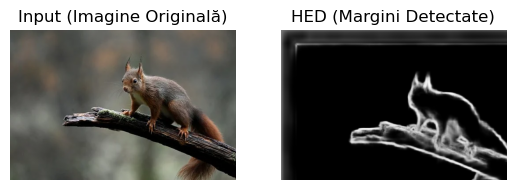

In [7]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("veverita.webp")
(H, W) = img.shape[:2]
blob = cv2.dnn.blobFromImage(img, scalefactor=1.0, size=(W, H),
    swapRB=False, crop=False)
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "hed_pretrained_bsds.caffemodel")
net.setInput(blob)
hed = net.forward()
hed = cv2.resize(hed[0, 0], (W, H))
hed = (255 * hed).astype("uint8")

# Imaginea de intrare
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input (Imagine Originală)")
plt.axis('off') 

# Rezultatul HED
plt.subplot(1, 2, 2)
plt.imshow(hed, cmap='gray')
plt.title("HED (Margini Detectate)")
plt.axis('off') 

plt.show()



### Comparație între detectoare de muchii: Canny, Sobel și HED
În această secțiune sunt comparate trei metode de detecție a marginilor:

- **Sobel** – operator clasic bazat pe calculul gradientului pe direcțiile X și Y;
- **Canny** – algoritm multi-etapă care include filtrare Gaussiană, calculul gradientului, subpresia non-maximelor și histereza;
- **HED (Holistically-Nested Edge Detection)** – metodă modernă bazată pe rețele neuronale convoluționale, care învață automat structura marginilor din imagini reale.

Rezultatele evidențiază diferența între abordările tradiționale (filtre fixe) și cea învățată (*data-driven*), în care muchiile detectate sunt mai netede, mai continue și mai apropiate de percepția umană.


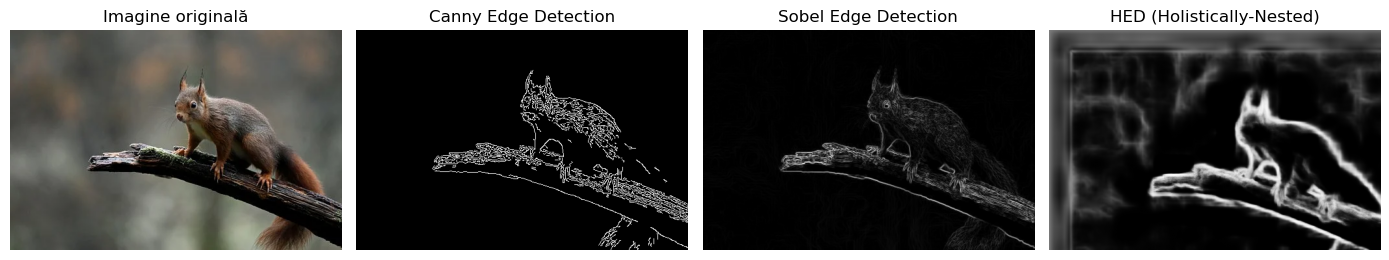

In [24]:
# -------------------------------
# COMPARAȚIE: HED vs CANNY vs SOBEL
# -------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("veverita.webp")
if img is None:
    raise FileNotFoundError("Imaginea 'veverita.webp' nu a fost găsită. Verifică calea!")
(H, W) = img.shape[:2]

# Conversie la gri pentru Canny și Sobel
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#  --- CANNY ---
edges_canny = cv2.Canny(gray, 100, 200)

#  --- SOBEL ---
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
edges_sobel = np.sqrt(sobelx**2 + sobely**2)
edges_sobel = cv2.normalize(edges_sobel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

#  --- HED ---
# Creare blob pentru modelul DNN
blob = cv2.dnn.blobFromImage(
    img,
    scalefactor=1.0,
    size=(W, H),
    mean=(104.00698793, 116.66876762, 122.67891434),  # valori medii pentru VGG
    swapRB=False,
    crop=False
)

# Încărcare model HED preantrenat
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "hed_pretrained_bsds.caffemodel")

# Inference
net.setInput(blob)
hed = net.forward()
hed = cv2.resize(hed[0, 0], (W, H))
hed = (255 * hed).astype("uint8")

# --- Afișare rezultate ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagine originală")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(edges_canny, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(edges_sobel, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(hed, cmap='gray')
plt.title("HED (Holistically-Nested)")
plt.axis("off")

plt.tight_layout()
plt.show()


# Kornia – bibliotecă PyTorch pentru viziune computerizată

- bibliotecă open-source construită peste PyTorch, concepută pentru a realiza procesări de imagini și viziune computerizată în mod complet diferentiabil.
- ermite integrarea directă a operațiilor clasice (filtrare, detecție de muchii, transformări geometrice, blur etc.) în fluxuri de antrenare deep learning.

Practic, Kornia oferă o punte între metodele tradiționale de procesare a imaginilor (Sobel, Canny, HOG, SIFT) și rețelele neuronale moderne, permițând ca aceste operații să fie folosite ca layere în rețele CNN și optimizate automat prin backpropagation.

Pentru detecția muchiilor, Kornia include implementări complet diferentiabile ale algoritmilor Sobel, Canny și filtre Gaussian, utile atât pentru analiză vizuală, cât și pentru învățarea reprezentărilor de margini în rețele neurale.

articol: https://arxiv.org/pdf/2009.10521

articol(10pag): https://openaccess.thecvf.com/content_WACV_2020/papers/Riba_Kornia_an_Open_Source_Differentiable_Computer_Vision_Library_for_PyTorch_WACV_2020_paper.pdf

experiment preluat de pe: https://www.kaggle.com/code/venkatkumar001/hed-kornia-opencv-edge-detection-part-i

In [34]:
#Install kornia

!pip install kornia

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 10.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   -- ------------------------------------- 7.9/109.3 MB 39.4 MB/s eta 0:00:03
   ------ --------------------------------- 16.5/109.3 MB 40.3 MB/s eta 0:00:03
   --------- ------------------------------ 25.2/109.3 MB 40.4 MB/s eta 0:00:03
   ------------ --------------------------- 33.0/109.3 MB 39.0 MB/s eta 0:00:02
   --------------- ------------------------ 42.2/109.3 MB 39.5 MB/s eta 0:00:02
   ------------------ --------------------- 50.3/109.3 MB 39.6 MB/s eta 0:00:02
   --------------------- ------------------ 59.2/109.3 MB 39.8 MB/s eta 0:00:02
   ------------------------ --------------- 67.9/109.3 MB 39.8 MB/s eta 0:00:0

In [28]:
import torch
import torchvision
import kornia as ki

In [37]:
pip install torchvision

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ----------------- ---------------------- 1.8/4.3 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 21.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [29]:
#load input and read image color 
#Cv2 represent the output in numpy array
img_input= cv2.imread('lion.png',cv2.IMREAD_COLOR)

In [30]:
# Kornia generally torch based one! so we are convert numpy to torch

img_input = ki.utils.image_to_tensor(img_input) 
img_input = img_input[None,...].float() / 255.

In [31]:
def imshow(input: torch.Tensor):
    out = torchvision.utils.make_grid(input, nrow=2, padding=5)
    out_np: np.ndarray = ki.utils.tensor_to_image(out)
    plt.figure(figsize=(10,10))
    plt.imshow(out_np)
    plt.axis('off')
    plt.show()

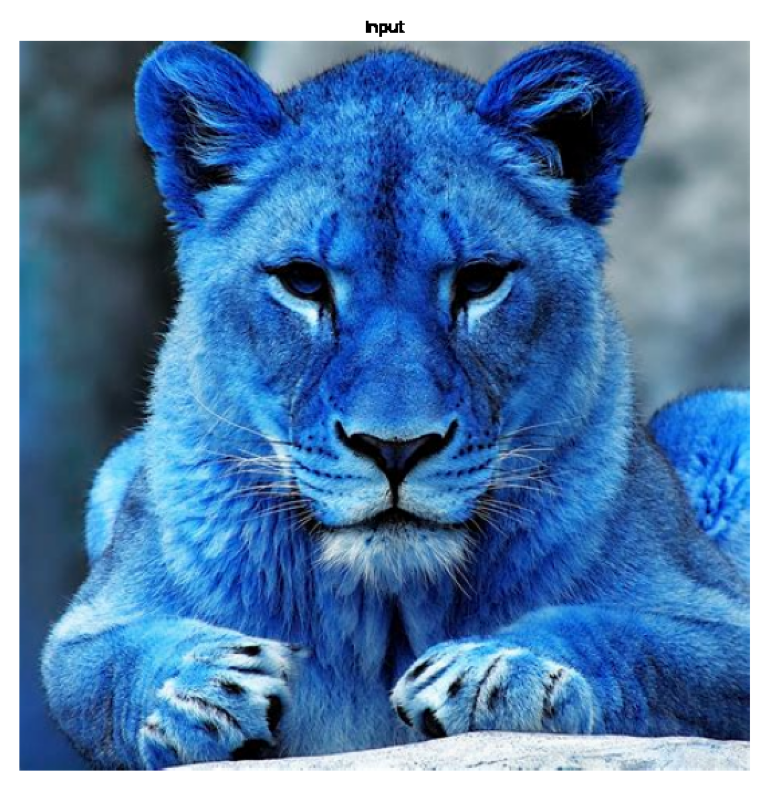

In [32]:
imshow(img_input)

In [33]:
#Covert first bgr to rgb
#And rgb to gray

img_rgb = ki.color.bgr_to_rgb(img_input)
img_gray = ki.color.rgb_to_grayscale(img_rgb)

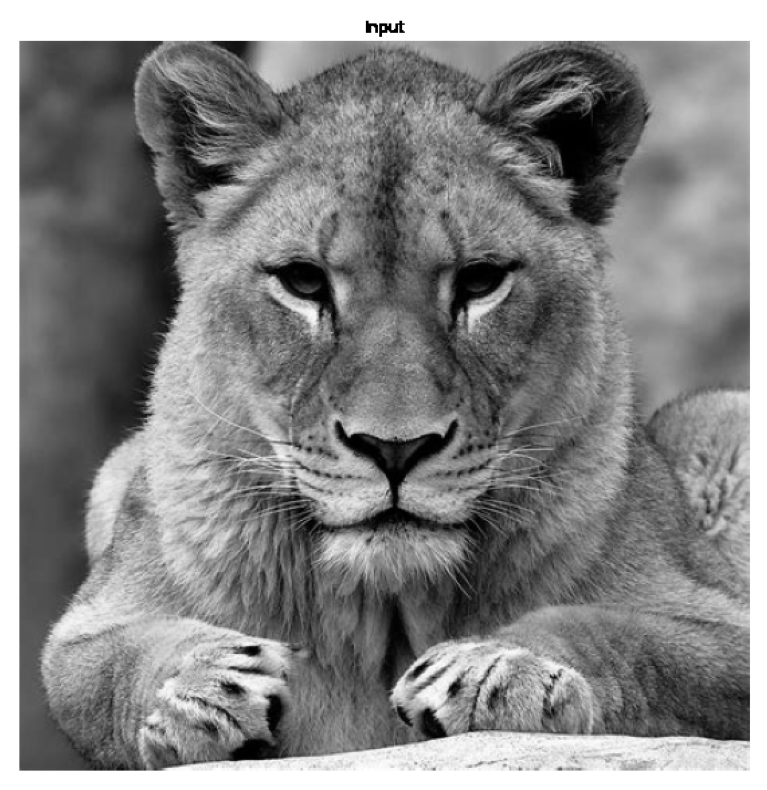

In [34]:
imshow(img_gray)

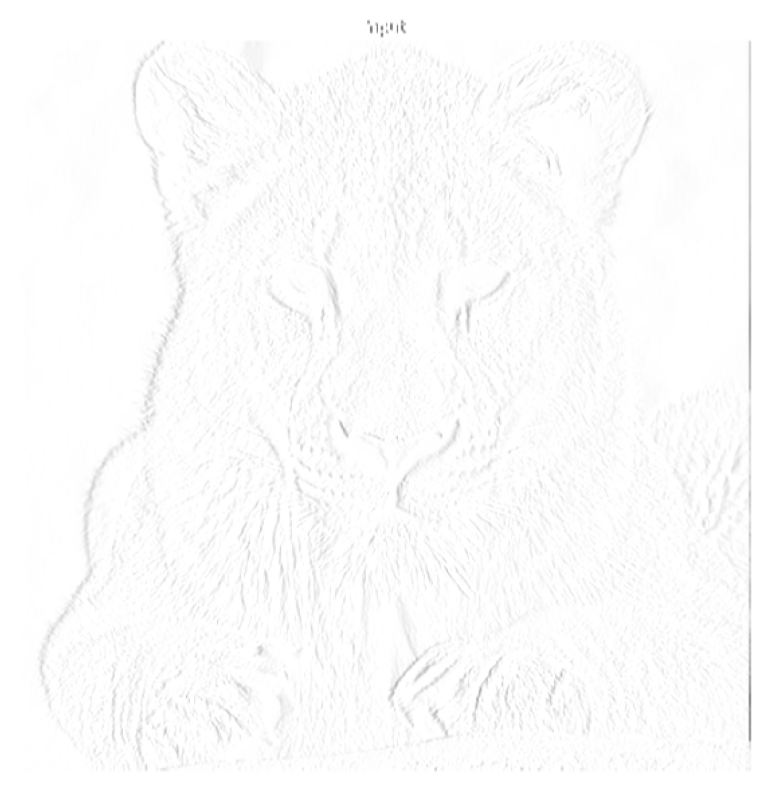

In [41]:
#first order derivates

img_grad = ki.filters.spatial_gradient(img_gray, order=1)  # BxCx2xHxW
img_grads_x = img_grad[:, :, 0]
img_grads_y = img_grad[:, :, 1]

# first derviative in x
imshow(1. - img_grads_x.clamp(0., 1.))

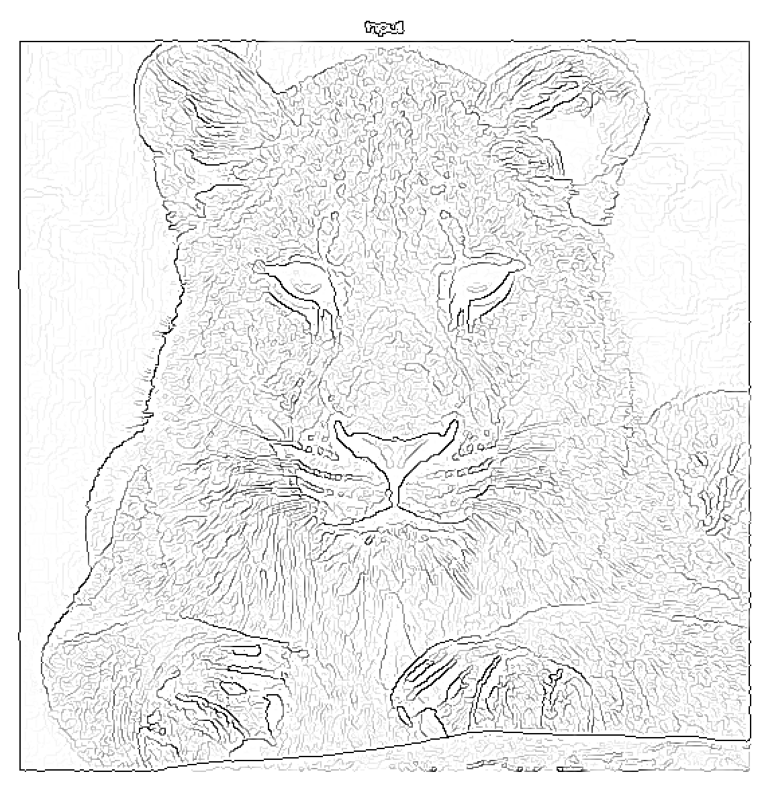

In [38]:
#canny edges
img_canny= ki.filters.canny(img_gray)[0]
imshow(1. - img_canny.clamp(0., 1.))

# Trying HED, Canny, Kornia comparison on BSDS500 dataset 

baza de date a fost descarcata de pe kaggle: https://www.kaggle.com/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500?select=images

In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import torch
import kornia as K
from tqdm import tqdm


Am folosit o funcție de evaluare care permite marjă de eroare de 2 pixeli (toleranță), similar cu protocolul BSDS.

In [7]:
from scipy.ndimage import binary_dilation

def evaluate_edges_tolerant(pred, gt, tolerance=2):
    """
    Comparație între predicție și ground truth cu o toleranță spațială (în pixeli).
    """
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    
    # dilatare: extinde muchiile pentru a permite o marjă de eroare
    gt_dilated = binary_dilation(gt, iterations=tolerance)
    pred_dilated = binary_dilation(pred, iterations=tolerance)
    
    # true positive = muchii prezise care se suprapun cu GT dilatat
    tp = np.sum(pred & gt_dilated)
    fp = np.sum(pred & (~gt_dilated))
    fn = np.sum(gt & (~pred_dilated))
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return precision, recall, f1


In [8]:
import os

images_dir = r"D:\Programe\1MASTER\an2\procesareImagini\BSDS500\data\test"
gt_dir = r"D:\Programe\1MASTER\an2\procesareImagini\BSDS500\groundTruth\test"

if not os.path.exists(images_dir):
    raise FileNotFoundError(f"Nu am găsit directorul de imagini: {images_dir}")

if not os.path.exists(gt_dir):
    raise FileNotFoundError(f"Nu am găsit directorul de ground truth: {gt_dir}")

image_files = sorted([
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".jpg", ".png"))
])

print(f"{len(image_files)} imagini găsite în {images_dir}:")
print(image_files[:5])


200 imagini găsite în D:\Programe\1MASTER\an2\procesareImagini\BSDS500\data\test:
['100007.jpg', '100039.jpg', '100099.jpg', '10081.jpg', '101027.jpg']


In [9]:
protoPath = "deploy.prototxt"
modelPath = "hed_pretrained_bsds.caffemodel"

try:
    net = cv2.dnn.readNetFromCaffe(protoPath, modelPath)
except cv2.error as e:
    print(f"Eroare la încărcarea modelului: {e}")


In [10]:
def run_canny(img_gray):
    return cv2.Canny(img_gray, 100, 200)

def run_kornia(img_gray):
    img_t = K.image_to_tensor(img_gray, keepdim=False).float() / 255.0
    edges = K.filters.Canny()(img_t)
    return (edges[0][0].numpy() * 255).astype(np.uint8)

def run_hed(img_bgr):
    H, W = img_bgr.shape[:2]
    blob = cv2.dnn.blobFromImage(img_bgr, scalefactor=1.0, size=(W, H),
                                 mean=(104.00698793, 116.66876762, 122.67891434),
                                 swapRB=False, crop=False)
    net.setInput(blob)
    hed_output = net.forward()
    hed_map = cv2.resize(hed_output[0, 0], (W, H))
    return (255 * hed_map).astype("uint8")


In [12]:
from scipy.io import loadmat
from tqdm import tqdm

results = {"Canny": [], "HED": [], "Kornia": []}

for fname in tqdm(image_files):
    img_path = os.path.join(images_dir, fname)
    gt_path = os.path.join(gt_dir, fname.replace(".jpg", ".mat").replace(".png", ".mat"))
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Eroare: nu pot citi imaginea {fname}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Citim ground truth-ul (.mat)
    try:
        mat = loadmat(gt_path)
        # În fișierul .mat, sunt mai multe etichete, alegem prima (0,0)
        gt_struct = mat['groundTruth'][0]
        gt = gt_struct[0]['Boundaries'][0, 0].astype(np.uint8)
    except Exception as e:
        print(f"Eroare la citirea ground truth pentru {fname}: {e}")
        continue

    # Rulăm toate metodele
    edges_canny = run_canny(gray)
    edges_hed = run_hed(img)
    edges_kornia = run_kornia(gray)
    
    # Evaluare metrici
    for method, edges in zip(["Canny", "HED", "Kornia"], [edges_canny, edges_hed, edges_kornia]):
        p, r, f1 = evaluate_edges_tolerant(edges, gt, tolerance=2)
        results[method].append((p, r, f1))


100%|██████████| 200/200 [02:45<00:00,  1.21it/s]


In [16]:
import numpy as np
import pandas as pd

def summarize_results(results):
    summary = {}
    for method, vals in results.items():
        vals = np.array(vals)
        # Calculează media pentru Precision, Recall și F1
        mean_p, mean_r, mean_f1 = vals.mean(axis=0)
        
        summary[method] = {
            "Mean Precision": float(mean_p),
            "Mean Recall": float(mean_r),
            "Mean F1 (OIS)": float(mean_f1)
        }
    return summary

summary_data = summarize_results(results)

df = pd.DataFrame.from_dict(summary_data, orient='index')

df_display = (df * 100).round(2)

print("Tabelul cu Metricile de Evaluare")
df_display

Tabelul cu Metricile de Evaluare BSDS500:


,Mean Precision,Mean Recall,Mean F1 (OIS)
Canny,18.57,82.93,28.72
HED,8.58,91.50,15.46
Kornia,8.60,97.43,15.56


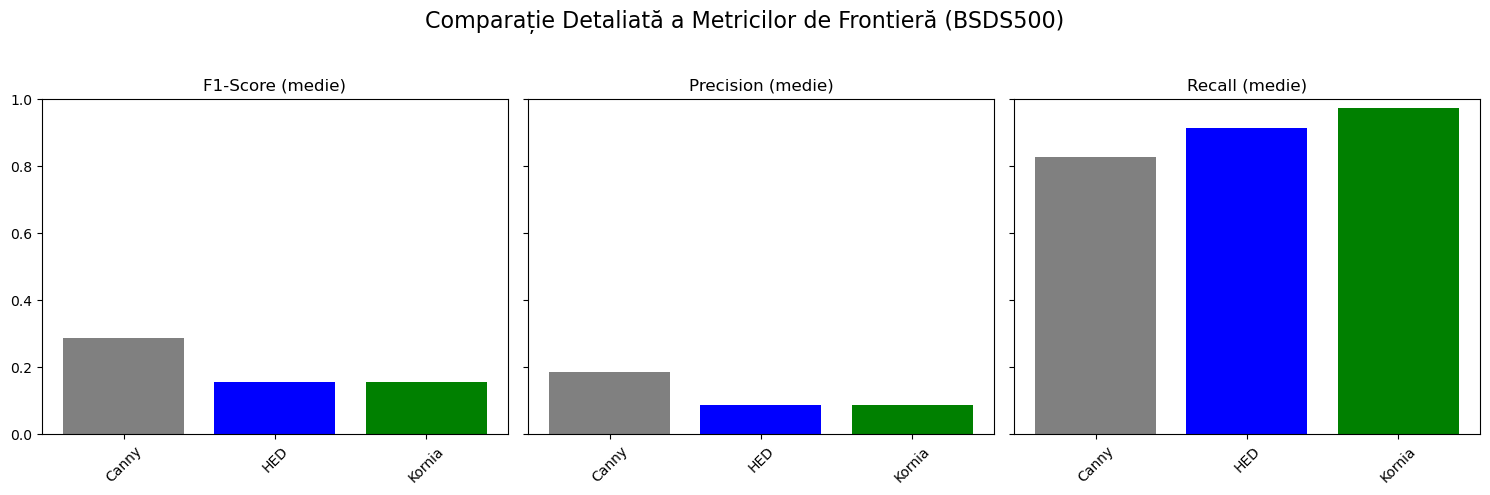

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

summary_data = pd.DataFrame.from_dict(summary, orient='index')

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True) # sharey=True menține scara axei y

metrics = ["Mean F1 (OIS)", "Mean Precision", "Mean Recall"]
titles = ["F1-Score (medie)", "Precision (medie)", "Recall (medie)"]
colors = ['gray', 'blue', 'green'] 

for i, metric in enumerate(metrics):
    ax[i].bar(summary_data.index, summary_data[metric], color=colors)
    ax[i].set_title(titles[i])
    ax[i].tick_params(axis='x', rotation=45) # Rotim etichetele X
    ax[i].set_ylim(0, 1.0) # scala Y de la 0 la 1.0 

fig.suptitle("Comparație Detaliată a Metricilor de Frontieră (BSDS500)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##### Observatie
- scorurile F1 obținute (Mean F1/OIS) sunt semnificativ mai mici decât benchmark-ul BSDS (care ar trebui să fie în jur de 0.75-0.81)
- acest lucru se datorează în principal Precision-ului scăzut, cauzat de lipsa subțierii (thinning) pe marginile HED/Kornia și de protocolul simplificat de evaluare
- viitoare îmbunătățire: pt a obține scoruri conforme standardului, trebuie utilizat pyEdgeEval, care implementează matching-ul tolerant la erori și calculează ODS, OIS și AP corecte.

### Comparatie vizuala

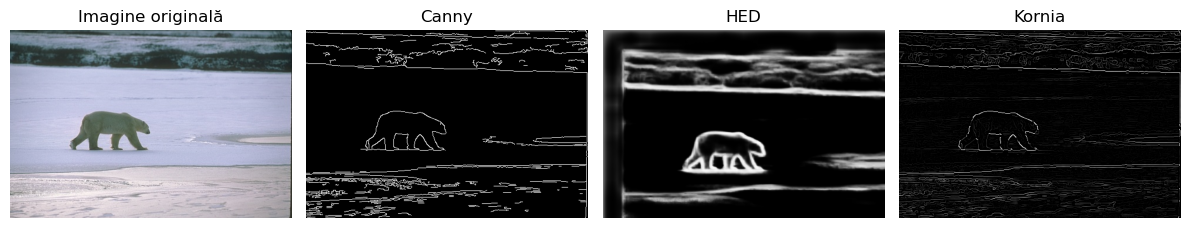

In [19]:
idx = 0
fname = image_files[idx]
img = cv2.imread(os.path.join(images_dir, fname))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges_canny = run_canny(gray)
edges_hed = run_hed(img)
edges_kornia = run_kornia(gray)

plt.figure(figsize=(12,6))
plt.subplot(1,4,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Imagine originală"); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(edges_canny, cmap='gray'); plt.title("Canny"); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(edges_hed, cmap='gray'); plt.title("HED"); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(np.squeeze(edges_kornia), cmap='gray'); plt.title("Kornia"); plt.axis('off') # np.squeeze aplicat pentru a elimina dimensiunea inutilă de 'batch' (forma (1, H, W) -> (H, W)), pentru care era o eroare si nu se afisa imaginea
plt.tight_layout()
plt.show()

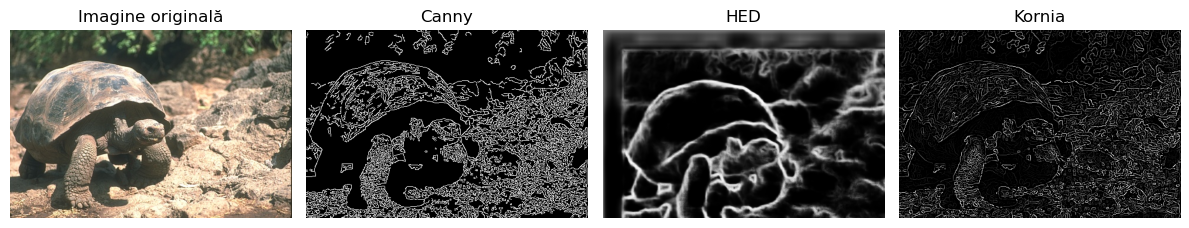

In [43]:
idx = 7
fname = image_files[idx]
img = cv2.imread(os.path.join(images_dir, fname))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges_canny = run_canny(gray)
edges_hed = run_hed(img)
edges_kornia = run_kornia(gray)

plt.figure(figsize=(12,6))
plt.subplot(1,4,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Imagine originală"); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(edges_canny, cmap='gray'); plt.title("Canny"); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(edges_hed, cmap='gray'); plt.title("HED"); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(np.squeeze(edges_kornia), cmap='gray'); plt.title("Kornia"); plt.axis('off') # np.squeeze aplicat pentru a elimina dimensiunea inutilă de 'batch' (forma (1, H, W) -> (H, W)), pentru care era o eroare si nu se afisa imaginea
plt.tight_layout()
plt.show()

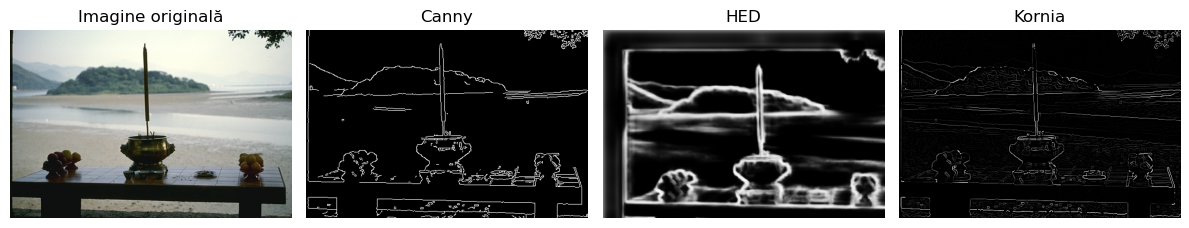

In [44]:
idx = 28
fname = image_files[idx]
img = cv2.imread(os.path.join(images_dir, fname))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges_canny = run_canny(gray)
edges_hed = run_hed(img)
edges_kornia = run_kornia(gray)

plt.figure(figsize=(12,6))
plt.subplot(1,4,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Imagine originală"); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(edges_canny, cmap='gray'); plt.title("Canny"); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(edges_hed, cmap='gray'); plt.title("HED"); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(np.squeeze(edges_kornia), cmap='gray'); plt.title("Kornia"); plt.axis('off') # np.squeeze aplicat pentru a elimina dimensiunea inutilă de 'batch' (forma (1, H, W) -> (H, W)), pentru care era o eroare si nu se afisa imaginea
plt.tight_layout()
plt.show()

# DEXINET

In [64]:
# -------------------------------
# INSTALARE DEXINED (din Hugging Face)
# -------------------------------
!pip install torch torchvision --quiet
#!pip install transformers accelerate huggingface_hub --quiet
!pip install opencv-python matplotlib numpy --quiet


In [66]:
# -------------------------------
# ÎNCĂRCARE MODEL DEXINED
# -------------------------------

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Detectare GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Se folosește dispozitivul: {device.upper()}")

# Încărcare model direct din GitHub
model = torch.hub.load("xavysp/DexiNed", "dexined", pretrained=True).to(device)
model.eval()


Se folosește dispozitivul: CPU


D:\Apps\Anaconda\Lib\site-packages\torch\hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/xavysp/DexiNed/zipball/master" to C:\Users\Viviana/.cache\torch\hub\master.zip


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Viviana/.cache\\torch\\hub\\xavysp_DexiNed_master\\hubconf.py'

In [ ]:
# -------------------------------
# DETECȚIA MUCHIILOR CU DEXINED
# -------------------------------

# Imaginea ta
img = cv2.imread("veverita.webp")
if img is None:
    raise FileNotFoundError("Nu s-a găsit imaginea 'veverita.webp' în directorul curent!")

# Conversie și redimensionare
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (512, 512))

# Conversie la tensor Torch
tensor_img = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0) / 255.0
tensor_img = tensor_img.to(device)

# Inferență
with torch.no_grad():
    preds = model(tensor_img)

# Ultimul strat al modelului (harta marginilor)
edge_map = torch.mean(preds[-1], dim=1).squeeze().cpu().numpy()
edge_map = (edge_map * 255).astype(np.uint8)

# Afișare rezultate
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Imagine originală")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edge_map, cmap='gray')
plt.title("DexiNed - Marginile detectate")
plt.axis('off')
plt.show()
